In [10]:
#import relevant libraries: pip install re, pip install natsort, pip install plotly==5.10.0
import sys
import os
import glob

import numpy as np
import scipy as sp
import pandas as pd
import matplotlib as mpl
import datetime as dt8
import math
import matplotlib.pyplot as plt
import decimal
import re
from natsort import index_natsorted
import dabest
from datetime import datetime
date = datetime.today().strftime('%Y%m%d')

import NLCLIMB 
import NLGRAPHS
import NLMATH

import plotly.express as px 
from plotly.subplots import make_subplots
import plotly.graph_objects as go

#NOTE: SUPPRESSES WARNINGS!

import warnings

warnings.simplefilter(action="ignore", category=RuntimeWarning)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.simplefilter(action="ignore", category=FutureWarning)
warnings.simplefilter("ignore", UserWarning)

In [11]:
#initial file processing

workcomp = "C:\\Users\\User"
computer2 = "C:\\Users\\lnico"
officecomp = "C:\\Users\\Star"
homecomp = "D:"
specifiedpath = workcomp

#Comment depending on project type
eopn3work = "Y"
eopn3work = "tgt"

if eopn3work == "Y":
    whomst = "NL"
    filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\2. Processed\\" + whomst + "\\"
    savefiglocation = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data compilation\\images\\"
    
if eopn3work == "tgt":
    filedir = "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\2. Processed\\"
    savefiglocation = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\eOPN3 manuscript\\Data Compilation\\Together\\images\\"
    
    
openPath = specifiedpath + filedir
files = os.listdir(openPath)

#identifying genotypes
responder = "eOPN3"     
driver = "elav"
wt = "w1118"
transgenic = driver + " x " + responder
filename = openPath + transgenic + ".csv"
filenamewt = openPath + wt+"_"+ transgenic + ".csv"

# For compatibility with streamlined variables
expt_file = filename
wt_file = filenamewt
figure_dir = savefiglocation

print(filename)
print(filenamewt)

C:\Users\User\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data Compilation\Together\2. Processed\elav x eOPN3.csv
C:\Users\User\ACC Lab Dropbox\ACC Lab\Nicole Lee\eOPN3 manuscript\Data Compilation\Together\2. Processed\w1118_elav x eOPN3.csv


In [12]:

# Set up Inter font
inter_font_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Regular.ttf"
inter_bold_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Bold.ttf"
inter_italic_path = specifiedpath + "\\ACC Lab Dropbox\\ACC Lab\\Nicole Lee\\Programs\\extras\\ttf\\Inter-Italic.ttf"

# Register fonts
import matplotlib.font_manager as fm
fm.fontManager.addfont(inter_font_path)
fm.fontManager.addfont(inter_bold_path)
fm.fontManager.addfont(inter_italic_path)

# Set Inter as default font
plt.rcParams['font.family'] = 'Inter'

# functions

In [13]:
def falldbest_with_recovery(df, name):
    """Process falls data including Recovery phase using NLMATH pattern."""
    phases = ['Dark', 'Full', 'Recovery']
    combined_data = pd.DataFrame()
    
    for phase in phases:
        phase_df = pd.DataFrame()
        df_phase = df[df['ExperimentState'] == phase]
        filtered_falls = df_phase.filter(regex="Fall.*").sum(axis=0)
        phase_df['Falls'] = filtered_falls
        phase_df['ExperimentState'] = phase
        phase_df = phase_df.reset_index()
        combined_data = pd.concat([combined_data, phase_df], axis=0)
    
    combined_data['Type'] = name
    return combined_data

def velodabest_with_recovery(df, type_name):
    """Process velocity data including Recovery phase using NLMATH pattern."""
    phases = ["Dark", "Full", "Recovery"]
    combined_data = pd.DataFrame()
    
    for phase in phases:
        velocity_processed = NLMATH.calcgraph(df, "Velocity.*")
        phase_data = velocity_processed[velocity_processed['ExperimentState'] == phase]
        
        phase_df = pd.DataFrame()
        phase_df['Velocity'] = phase_data.iloc[:, 2:].mean(axis=0)
        phase_df["ExperimentState"] = phase
        combined_data = pd.concat([combined_data, phase_df])
    
    combined_data["Type"] = type_name
    
    # Remove null values like the original function
    if any(combined_data['Velocity'].isnull()):
        null_indices = combined_data[combined_data['Velocity'].isnull()].index.tolist()
        combined_data = combined_data.drop(index=null_indices)
    
    return combined_data

def separation_with_recovery(df_expt, df_wt, metric):
    """Process metric data across phases including Recovery using original pattern."""
    # Separate data by experimental phase
    expt_phases = {
        'Dark': df_expt[df_expt['ExperimentState'] == 'Dark'],
        'Full': df_expt[df_expt['ExperimentState'] == 'Full'], 
        'Recovery': df_expt[df_expt['ExperimentState'] == 'Recovery']
    }
    
    wt_phases = {
        'Dark': df_wt[df_wt['ExperimentState'] == 'Dark'],
        'Full': df_wt[df_wt['ExperimentState'] == 'Full'],
        'Recovery': df_wt[df_wt['ExperimentState'] == 'Recovery']
    }
    
    filter_pattern = metric + ".*"
    
    # Process experimental data
    expt_results = []
    for phase_name, phase_data in expt_phases.items():
        filtered_data = phase_data.filter(regex=filter_pattern)
        if metric == "Y":
            result = filtered_data.mean(axis=0)
        elif metric == "Fall":
            result = filtered_data.sum(axis=0) / 1
        else:
            result = filtered_data.mean(axis=0)
        expt_results.append((result, phase_name))
    
    # Process wild-type data
    wt_results = []
    for phase_name, phase_data in wt_phases.items():
        filtered_data = phase_data.filter(regex=filter_pattern)
        if metric == "Y":
            result = filtered_data.mean(axis=0)
        elif metric == "Fall":
            result = filtered_data.sum(axis=0) / 1
        else:
            result = filtered_data.mean(axis=0)
        wt_results.append((result, phase_name))
    
    # Build experimental dataframes
    expt_dfs = []
    for result, phase in expt_results:
        phase_df = pd.DataFrame({metric: result, 'ExperimentState': phase})
        expt_dfs.append(phase_df)
    
    expt_combined = pd.concat(expt_dfs).reset_index()
    expt_combined["Type"] = "Expt"
    
    # Build wild-type dataframes
    wt_dfs = []
    for result, phase in wt_results:
        phase_df = pd.DataFrame({metric: result, 'ExperimentState': phase})
        wt_dfs.append(phase_df)
    
    wt_combined = pd.concat(wt_dfs).reset_index()
    wt_combined["Type"] = "WT"
    
    # Combine all data
    final_data = pd.concat([expt_combined, wt_combined])
    return final_data

def totalheight_with_recovery(df_expt, df_wt, driver_name):
    """Prepare height data with Recovery phase using original pattern."""
    height_data = separation_with_recovery(df_expt, df_wt, "Y")
    height_data.loc[height_data['Type'] == 'Expt', 'Type'] = driver_name
    height_data['genre'] = height_data['ExperimentState'] + " " + height_data['Type']
    return height_data

# total to run before graphs

In [14]:
# Load and preprocess data
experimental_data = pd.read_csv(expt_file)
wildtype_data = pd.read_csv(wt_file)

# Remove index columns and apply NLCLIMB processing
processed_expt = NLCLIMB.fivesecondrule(NLCLIMB.generation(experimental_data.drop(experimental_data.columns[[0]], axis=1), driver))
processed_wt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wildtype_data.drop(wildtype_data.columns[[0]], axis=1), wt))

# Falls data processing using recovery-compatible functions
expt_falls = falldbest_with_recovery(processed_expt, "Expt")
wt_falls = falldbest_with_recovery(processed_wt, "WT")

falls_data = pd.concat([expt_falls, wt_falls], axis=0).reset_index(drop=True)
falls_data['Type'] = falls_data['Type'].replace("Expt", driver)
falls_data['genre'] = falls_data['ExperimentState'] + " " + falls_data['Type']
falls_data['value'] = 0
falls_data.loc[(falls_data['Falls'] > 0), ['value']] = 1

# Create falls DABEST object
falls_dabest = dabest.load(
    data=falls_data, 
    idx=(("Dark WT", "Full WT", "Recovery WT"), 
         ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
    x="genre", 
    y="value", 
    proportional=True, 
    paired="baseline", 
    id_col="index"
)

# Height data processing using recovery-compatible functions
height_data = totalheight_with_recovery(processed_expt, processed_wt, driver)

height_dabest = dabest.load(
    data=height_data, 
    idx=(("Dark WT", "Full WT", "Recovery WT"), 
         ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
    x="genre", 
    y="Y", 
    paired="baseline", 
    id_col="index"
)

# Velocity data processing using recovery-compatible functions
expt_velocity = velodabest_with_recovery(processed_expt, "Expt")
wt_velocity = velodabest_with_recovery(processed_wt, "WT")

velocity_data = pd.concat([expt_velocity, wt_velocity]).reset_index(drop=False)
velocity_data.loc[velocity_data['Type'] == 'Expt', 'Type'] = driver
velocity_data['genre'] = velocity_data['ExperimentState'] + " " + velocity_data['Type']

velocity_dabest = dabest.load(
    data=velocity_data, 
    idx=(("Dark WT", "Full WT", "Recovery WT"), 
         ("Dark " + driver, "Full " + driver, "Recovery " + driver)),
    x="genre", 
    y="Velocity", 
    paired="baseline", 
    id_col="index"
)

# Graphs

Text(0.5, 0.98, 'nSyb x AsOPN3')

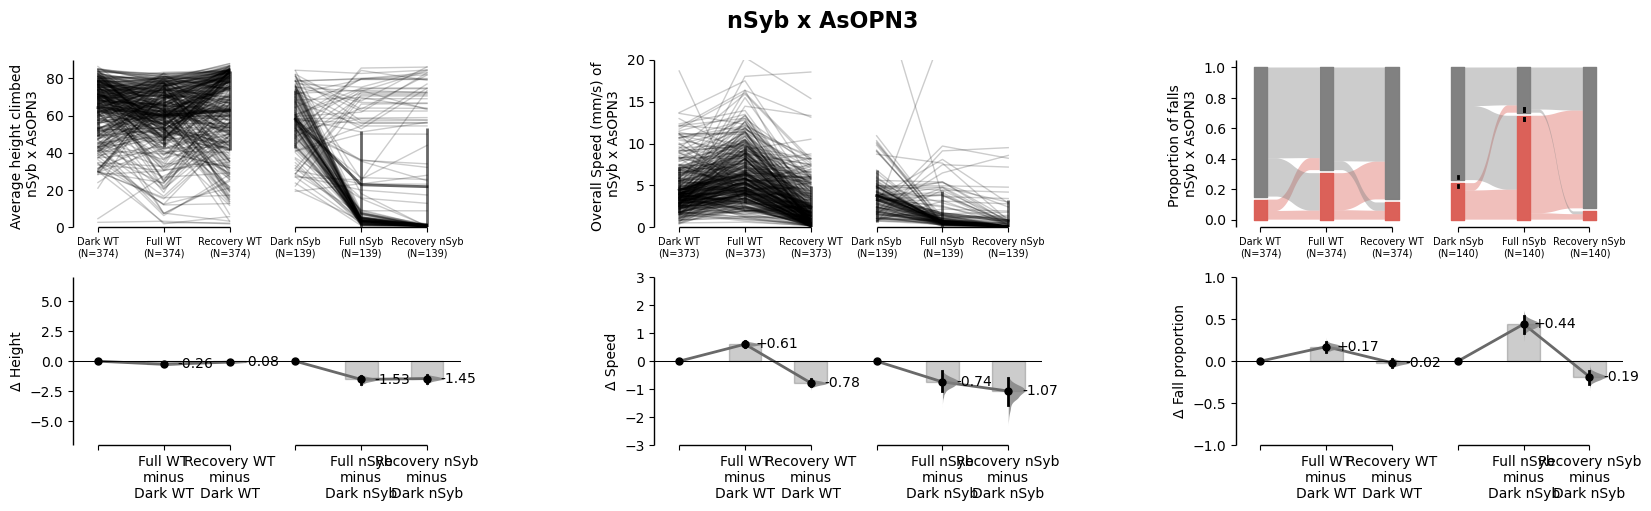

In [5]:
import seaborn as sns

# Format transgenic name for display
display_name = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

# Create and configure plots
fig, axes = plt.subplots(1, 3, figsize=(20, 5), gridspec_kw={'wspace': 0.5})

common_style = {'fontsize_rawxlabel': 7, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 10,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

# Height plot
height_dabest.hedges_g.plot(raw_label=f"Average height climbed \n{display_name}",
                            contrast_label="Δ Height", raw_ylim=(0, 90), contrast_ylim=(-7, 7),
                            ax=axes[0], **common_style)
#axes[0].legend_.remove()

# Velocity plot  
velocity_dabest.hedges_g.plot(raw_label=f"Overall Speed (mm/s) of \n{display_name}",
                              contrast_label="Δ Speed", raw_ylim=(0, 20), contrast_ylim=(-3, 3),
                              ax=axes[1], **common_style)
#axes[1].legend_.remove()

# Falls plot
falls_dabest.mean_diff.plot(raw_label=f"Proportion of falls \n{display_name}",
                            contrast_label="Δ Fall proportion", contrast_ylim=(-1, 1),
                            ax=axes[2], **common_style)

# Set title and save
fig.suptitle(display_name, fontsize=16, fontweight='bold')
#fig.savefig(savefiglocation + "threedabestplotsrecovery_" + date + "_" + transgenic + ".svg")

## Graphs for figure

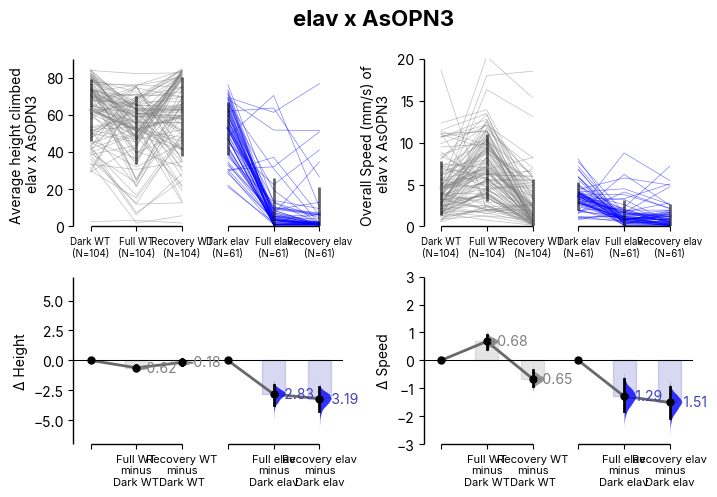

In [15]:
import seaborn as sns

# Format transgenic name for display
display_name2 = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

# Create and configure plots
fig2, axes2 = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'wspace': 0.3})

common_style = {'fontsize_rawxlabel': 7, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 8,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

# Define color palettes
gray_blue_palette = ["gray", "gray", "gray", "blue", "blue", "blue"]

# Create a function to determine line color based on index
def get_line_color(idx):
    """Returns gray for first 3 pairs (WT), blue for last 3 pairs (driver)"""
    return "gray" if idx < 3 else "blue"

# Height plot with colored paired lines
# For paired plots, slopegraph lines need color specified through slopegraph_kwargs
# We'll need to manually handle the coloring by creating a custom approach
height_dabest.hedges_g.plot(raw_label=f"Average height climbed \n{display_name2}", 
                            contrast_label="Δ Height", raw_ylim=(0, 90), contrast_ylim=(-7, 7),
                            custom_palette=gray_blue_palette,
                            slopegraph_kwargs={'linewidth': 0.5, 'alpha': 0.5},
                            ax=axes2[0], **common_style)

# After plotting, manually update line colors
for idx, line in enumerate(axes2[0].lines):
    # Skip error bar lines and other non-slopegraph lines
    if len(line.get_xdata()) == 3:  # Slopegraph lines connect 3 points
        # Determine which group this line belongs to
        if idx < len(axes2[0].lines) // 2:  # First half are WT lines
            line.set_color('gray')
        else:  # Second half are driver lines  
            line.set_color('blue')
        line.set_alpha(0.5)

# Velocity plot with colored paired lines
velocity_dabest.hedges_g.plot(raw_label=f"Overall Speed (mm/s) of \n{display_name2}",
                              contrast_label="Δ Speed", raw_ylim=(0, 20), contrast_ylim=(-3, 3),
                              custom_palette=gray_blue_palette,
                              slopegraph_kwargs={'linewidth': 0.5, 'alpha': 0.5},
                              ax=axes2[1], **common_style)

# After plotting, manually update line colors
for idx, line in enumerate(axes2[1].lines):
    # Skip error bar lines and other non-slopegraph lines
    if len(line.get_xdata()) == 3:  # Slopegraph lines connect 3 points
        # Determine which group this line belongs to
        if idx < len(axes2[1].lines) // 2:  # First half are WT lines
            line.set_color('gray')
        else:  # Second half are driver lines
            line.set_color('blue')
        line.set_alpha(0.5)

# Set title and save
fig2.suptitle(display_name2, fontsize=16, fontweight='bold')
mpl.rcParams['svg.fonttype'] = 'none' 
plt.rcParams['font.family'] = 'Inter'
#fig.savefig(savefiglocation + "threedabestplotsrecovery_" + date + "_" + transgenic + ".svg")

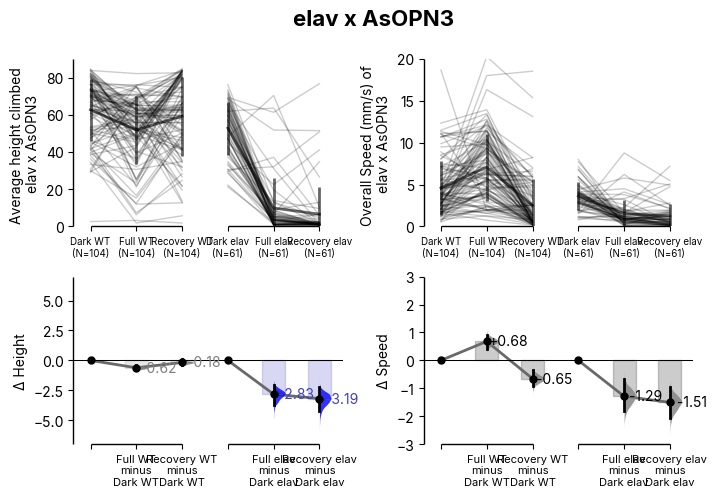

In [20]:
import seaborn as sns

# Format transgenic name for display
display_name2 = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

# Create and configure plots
fig2, axes2 = plt.subplots(1, 2, figsize=(8, 5), gridspec_kw={'wspace': 0.3})

common_style = {'fontsize_rawxlabel': 7, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 8,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

# Height plot
height_dabest.hedges_g.plot(raw_label=f"Average height climbed \n{display_name2}", 
                            contrast_label="Δ Height", raw_ylim=(0, 90), contrast_ylim=(-7, 7),custom_palette=["gray", "gray", "gray", "blue", "blue", "blue"],
                            ax=axes2[0], **common_style)

# Velocity plot  
velocity_dabest.hedges_g.plot(raw_label=f"Overall Speed (mm/s) of \n{display_name2}",
                              contrast_label="Δ Speed", raw_ylim=(0, 20), contrast_ylim=(-3, 3), swarmplot_kwargs={'palette': {"Dark WT": "gray", "Dark Full": "gray", "Dark Recovery": "gray", 
                                                                                                                              "Dark " + driver: "blue", "Full " + driver: "blue","Recovery" + driver: "blue"}},
                              ax=axes2[1], **common_style)

# Set title and save
fig2.suptitle(display_name2, fontsize=16, fontweight='bold')
mpl.rcParams['svg.fonttype'] = 'none' 
plt.rcParams['font.family'] = 'Inter'
#fig.savefig(savefiglocation + "threedabestplotsrecovery_" + date + "_" + transgenic + ".svg")

## LIGHT ON or Recovery only

In [24]:
height_data.genre.unique()

array(['Dark elav', 'Full elav', 'Recovery elav', 'Dark WT', 'Full WT',
       'Recovery WT'], dtype=object)

In [17]:
# Load and preprocess data
experimental_data = pd.read_csv(expt_file)
wildtype_data = pd.read_csv(wt_file)

# Remove index columns and apply NLCLIMB processing
processed_expt = NLCLIMB.fivesecondrule(NLCLIMB.generation(experimental_data.drop(experimental_data.columns[[0]], axis=1), driver))
processed_wt = NLCLIMB.fivesecondrule(NLCLIMB.generation(wildtype_data.drop(wildtype_data.columns[[0]], axis=1), wt))

# Height data processing using recovery-compatible functions
height_data = totalheight_with_recovery(processed_expt, processed_wt, driver)

height_dabest = dabest.load(data = height_data,
    x=["ExperimentState", "ExperimentState"], 
    y="Y", experiment = "Type",
    experiment_label= ['WT', driver],
    x1_level = ['Dark', 'Recovery'], paired = "baseline",
    delta2 = True
)

# Velocity data processing using recovery-compatible functions
expt_velocity = velodabest_with_recovery(processed_expt, "Expt")
wt_velocity = velodabest_with_recovery(processed_wt, "WT")

velocity_data = pd.concat([expt_velocity, wt_velocity]).reset_index(drop=False)
velocity_data.loc[velocity_data['Type'] == 'Expt', 'Type'] = driver
velocity_data['genre'] = velocity_data['ExperimentState'] + " " + velocity_data['Type']

velocity_dabest = dabest.load(
    data=velocity_data, 
    x=["ExperimentState", "ExperimentState"], 
    y="Velocity", experiment = "Type",
    experiment_label= ['WT', driver],
    x1_level = ['Dark', 'Recovery'], paired= "baseline",
    delta2 = True
)

IndexError: `id_col` must be specified if `paired` is assigned with a not NoneType value.

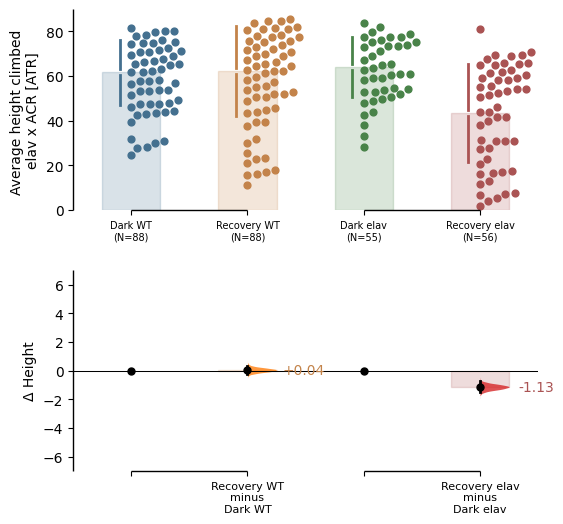

In [ ]:
import seaborn as sns

# Format transgenic name for display
display_name2 = (driver + " x " + responder.replace("eOPN3", "AsOPN3").replace("(iii)M4", " ") 
                if 'eOPN3' in responder else driver + " x " + responder)

# # Create and configure plots
# fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5), gridspec_kw={'wspace': 0.3})

common_style = {'fontsize_rawxlabel': 7, 'fontsize_rawylabel': 10, 'fontsize_contrastxlabel': 8,
                'fontsize_contrastylabel': 10, 'fontsize_delta2label': 10, 'contrast_marker_size': 5}

# Height plot
height_dabest.hedges_g.plot(raw_label=f"Average height climbed \n{display_name2}", 
                            contrast_label="Δ Height", raw_ylim=(0, 90), contrast_ylim=(-7, 7), show_delta2 = True,
                             **common_style);

# Velocity plot  
# velocity_dabest.hedges_g.plot(raw_label=f"Overall Speed (mm/s) of \n{display_name2}",
#                               contrast_label="Δ Speed", raw_ylim=(0, 20), contrast_ylim=(-3, 3), show_delta2 = True,
#                               ax=axes2[1], **common_style)

# Set title and save
# fig2.suptitle(display_name2, fontsize=16, fontweight='bold')
#fig.savefig(savefiglocation + "threedabestplotsrecovery_" + date + "_" + transgenic + ".svg")